# 03 — Exploratory Data Analysis

This notebook explores the cleaned AI patent dataset to identify:

- Trends over time
- Leading patent assignees
- Geographic patterns
- AI technology areas
- Patent complexity
- Citation patterns
- Relationships between patent characteristics

The objective is to translate these patterns into useful business insights.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

ROOT = Path.cwd().parent

PROCESSED_DIR = ROOT / "Data" / "processed"
FIGURES_DIR = ROOT / "Outputs" / "figures"
TABLES_DIR = ROOT / "Outputs" / "tables"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH = PROCESSED_DIR / "02_clean_patents.parquet"

df = pd.read_parquet(DATA_PATH)

print("Rows:", f"{len(df):,}")
print("Columns:", df.shape[1])

Rows: 80,566
Columns: 23


In [2]:
df.head()

,publication_number,application_number,family_id,publication_date,filing_date,grant_date,priority_date,grant_year,title,abstract,inventor_count,assignee_count,primary_assignee,assignee_country,cpc_count,primary_ai_cpc,cpc_group,backward_citation_count,title_word_count,abstract_word_count,claims_text_length,claims_word_count,filing_to_grant_days
0,US-10881345-B2,US-201715611953-A,59030779,2021-01-05,2017-06-02,2021-01-05,2016-06-03,2021,Method and system for estimation of stress of ...,A system and method for determining a stress l...,3,1,TATA CONSULTANCY SERVICES LTD,IN,17,G06N3/0499,G06N3,8,12.0,136.0,8263,1277,1313.0
1,US-10881348-B2,US-201715400287-A,49380436,2021-01-05,2017-01-06,2021-01-05,2012-02-27,2021,System and method for gathering and analyzing ...,Systems and methods for measuring biologically...,3,1,NIELSEN CO US LLC,US,18,G06N20/00,G06N20,744,18.0,145.0,9630,1497,1460.0
2,US-10881463-B2,US-201715690436-A,65436394,2021-01-05,2017-08-30,2021-01-05,2017-08-30,2021,Optimizing patient treatment recommendations u...,Patient treatment may be optimized using Recur...,6,1,IBM,US,13,G06N3/044,G06N3,22,15.0,125.0,11398,1686,1224.0
3,US-10881964-B1,US-201816130854-A,74045007,2021-01-05,2018-09-13,2021-01-05,2018-09-13,2021,Automated detection of emergent behaviors in i...,Various aspects of the subject technology rela...,1,1,ELECTRONIC ARTS INC,US,17,G06N3/045,G06N3,5,12.0,155.0,9597,1393,845.0
4,US-10882488-B2,US-201816048797-A,63207881,2021-01-05,2018-07-30,2021-01-05,2017-07-28,2021,Hardware and software mechanisms on autonomous...,An autonomous robot vehicle includes a front s...,4,1,NURO INC,US,110,G06N20/00,G06N20,21,10.0,100.0,6702,993,890.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 80566 entries, 0 to 80565
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   publication_number       80566 non-null  str           
 1   application_number       80566 non-null  str           
 2   family_id                80566 non-null  int64         
 3   publication_date         80566 non-null  datetime64[us]
 4   filing_date              79832 non-null  datetime64[us]
 5   grant_date               80566 non-null  datetime64[us]
 6   priority_date            79186 non-null  datetime64[us]
 7   grant_year               80566 non-null  int32         
 8   title                    80325 non-null  str           
 9   abstract                 79841 non-null  str           
 10  inventor_count           80566 non-null  int64         
 11  assignee_count           80566 non-null  int64         
 12  primary_assignee         80566 non-null  st

In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
publication_number,80566,80566,US-10881345-B2,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
application_number,80566,80566,US-201715611953-A,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
family_id,80566.0,NaN,NaN,NaN,75249387.352891,-1.0,69024728.0,75383073.0,82116993.5,99356795.0,10389955.977861
publication_date,80566,NaN,NaN,NaN,2023-10-08 21:23:47.113174,2021-01-05 00:00:00,2022-08-30 00:00:00,2023-10-10 00:00:00,2024-12-24 00:00:00,2026-04-21 00:00:00,NaN
filing_date,79832,NaN,NaN,NaN,2020-12-01 14:32:50.097204,1900-01-01 00:00:00,2019-09-30 00:00:00,2020-12-04 00:00:00,2022-03-21 00:00:00,2050-12-31 00:00:00,NaN
grant_date,80566,NaN,NaN,NaN,2023-10-08 21:23:47.113174,2021-01-05 00:00:00,2022-08-30 00:00:00,2023-10-10 00:00:00,2024-12-24 00:00:00,2026-04-21 00:00:00,NaN
priority_date,79186,NaN,NaN,NaN,2019-08-25 11:30:30.232616,1900-01-01 00:00:00,2018-08-02 00:00:00,2019-10-28 00:00:00,2020-12-21 00:00:00,2050-12-31 00:00:00,NaN
grant_year,80566.0,NaN,NaN,NaN,2023.283631,2021.0,2022.0,2023.0,2024.0,2026.0,1.457581
title,80325,65597,"System, method, and apparatus for providing dy...",184,NaN,NaN,NaN,NaN,NaN,NaN,NaN
abstract,79841,67604,"Systems, methods, and apparatuses for providin...",182,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
patents_by_year = (
    df.groupby("grant_year")
    .size()
    .reset_index(name="patent_count")
)

patents_by_year

,grant_year,patent_count
0,2021,11246
1,2022,15219
2,2023,17597
3,2024,16828
4,2025,15294
5,2026,4382


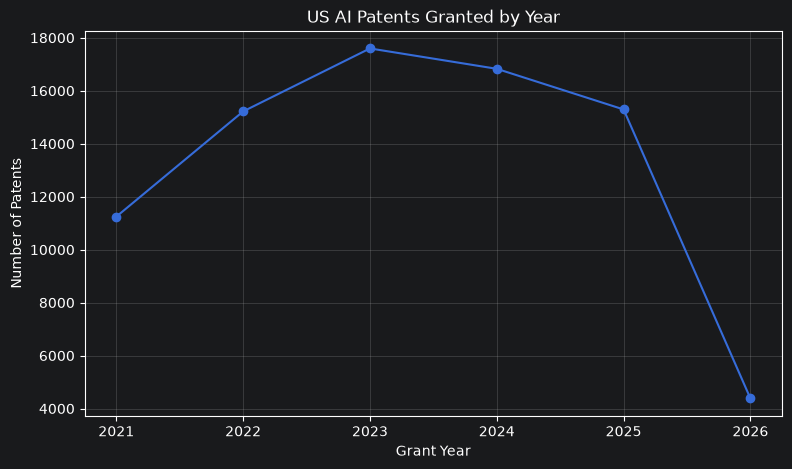

In [6]:
plt.figure(figsize=(9, 5))

plt.plot(
    patents_by_year["grant_year"],
    patents_by_year["patent_count"],
    marker="o"
)

plt.title("US AI Patents Granted by Year")
plt.xlabel("Grant Year")
plt.ylabel("Number of Patents")

plt.grid(alpha=0.3)

plt.show()

In [7]:
top_assignees = (
    df[df["primary_assignee"] != "Unknown"]
    ["primary_assignee"]
    .value_counts()
    .head(15)
    .reset_index()
)

top_assignees.columns = [
    "assignee",
    "patent_count"
]

top_assignees

,assignee,patent_count
0,IBM,5310
1,SAMSUNG ELECTRONICS CO LTD,2206
2,GOOGLE LLC,2062
3,MICROSOFT TECHNOLOGY LICENSING LLC,1997
4,CAPITAL ONE SERVICES LLC,1221
5,INTEL CORP,1205
6,AMAZON TECH INC,1196
7,ADOBE INC,890
8,BANK OF AMERICA,810
9,NVIDIA CORP,625


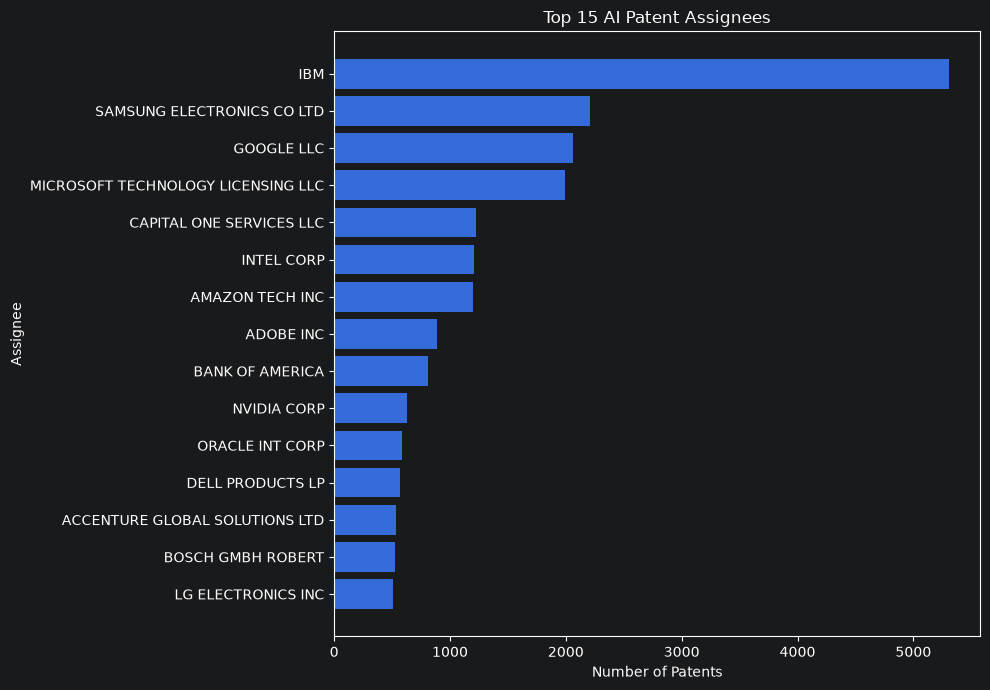

In [8]:
plt.figure(figsize=(10, 7))

plt.barh(
    top_assignees["assignee"][::-1],
    top_assignees["patent_count"][::-1]
)

plt.title("Top 15 AI Patent Assignees")
plt.xlabel("Number of Patents")
plt.ylabel("Assignee")

plt.tight_layout()
plt.show()

In [9]:
country_counts = (
    df["assignee_country"]
    .value_counts()
    .reset_index()
)

country_counts.columns = [
    "country",
    "patent_count"
]

country_counts.head(15)

,country,patent_count
0,US,50940
1,KR,5176
2,CN,5145
3,JP,4634
4,DE,2180
5,Unknown,1699
6,CA,1329
7,GB,1293
8,IL,1062
9,TW,871


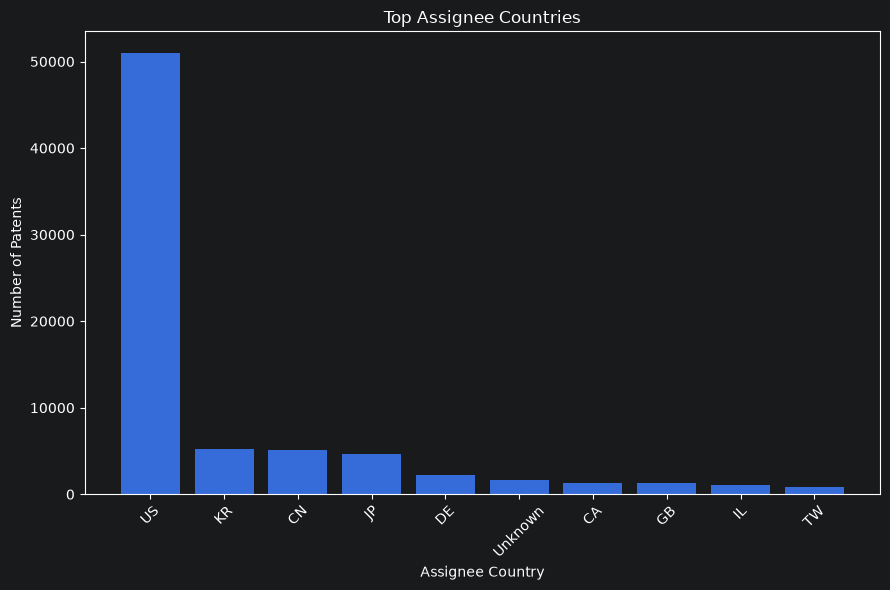

In [10]:
top_countries = country_counts.head(10)

plt.figure(figsize=(9, 6))

plt.bar(
    top_countries["country"],
    top_countries["patent_count"]
)

plt.title("Top Assignee Countries")
plt.xlabel("Assignee Country")
plt.ylabel("Number of Patents")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [11]:
cpc_group_counts = (
    df["cpc_group"]
    .value_counts()
    .reset_index()
)

cpc_group_counts.columns = [
    "cpc_group",
    "patent_count"
]

cpc_group_counts

,cpc_group,patent_count
0,G06N3,41981
1,G06N20,22218
2,G06N5,9418
3,G06N7,4091
4,G06N10,2783
5,G06N99,75


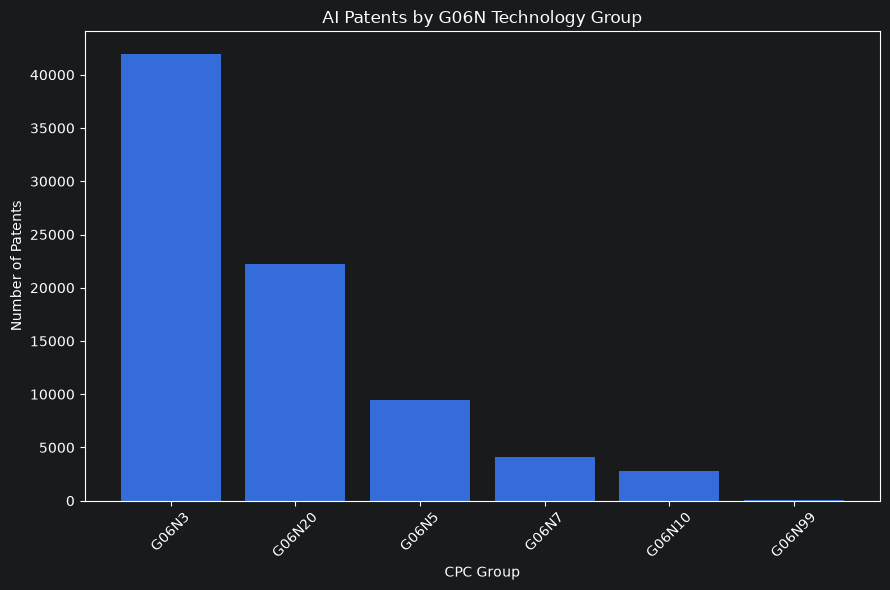

In [12]:
plt.figure(figsize=(9, 6))

plt.bar(
    cpc_group_counts["cpc_group"],
    cpc_group_counts["patent_count"]
)

plt.title("AI Patents by G06N Technology Group")
plt.xlabel("CPC Group")
plt.ylabel("Number of Patents")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [13]:
df["inventor_count"].describe()

count    80566.000000
mean         3.540042
std          2.350370
min          0.000000
25%          2.000000
50%          3.000000
75%          5.000000
max         36.000000
Name: inventor_count, dtype: float64

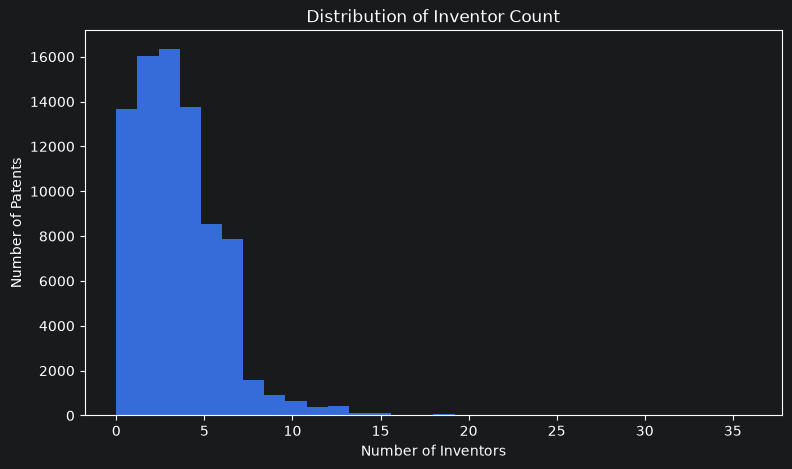

In [14]:
plt.figure(figsize=(9, 5))

plt.hist(
    df["inventor_count"].dropna(),
    bins=30
)

plt.title("Distribution of Inventor Count")
plt.xlabel("Number of Inventors")
plt.ylabel("Number of Patents")

plt.show()

In [15]:
df["cpc_count"].describe()

count    80566.000000
mean        13.298885
std         11.853232
min          1.000000
25%          7.000000
50%         11.000000
75%         16.000000
max        147.000000
Name: cpc_count, dtype: float64

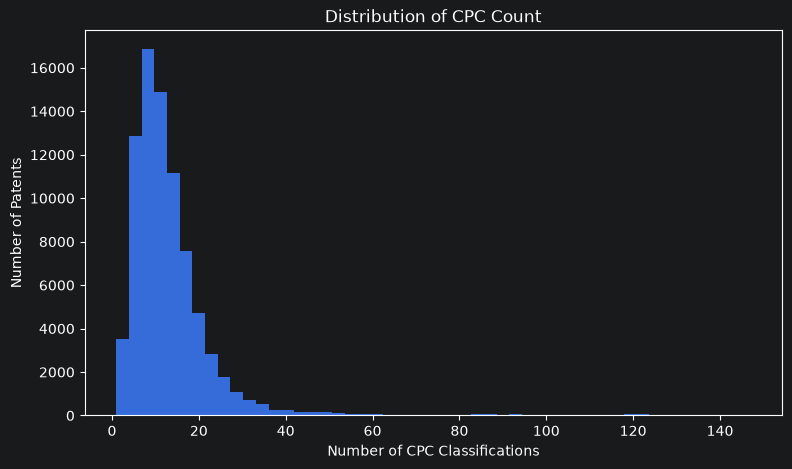

In [16]:
plt.figure(figsize=(9, 5))

plt.hist(
    df["cpc_count"].dropna(),
    bins=50
)

plt.title("Distribution of CPC Count")
plt.xlabel("Number of CPC Classifications")
plt.ylabel("Number of Patents")

plt.show()

In [17]:
df["backward_citation_count"].describe()

count    80566.000000
mean        37.143969
std        128.831438
min          0.000000
25%          7.000000
50%         13.000000
75%         25.000000
max       7566.000000
Name: backward_citation_count, dtype: float64

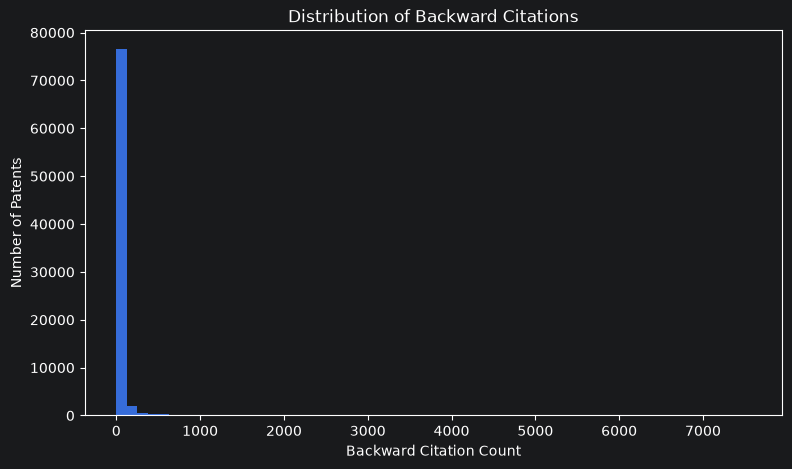

In [18]:
plt.figure(figsize=(9, 5))

plt.hist(
    df["backward_citation_count"].dropna(),
    bins=60
)

plt.title("Distribution of Backward Citations")
plt.xlabel("Backward Citation Count")
plt.ylabel("Number of Patents")

plt.show()

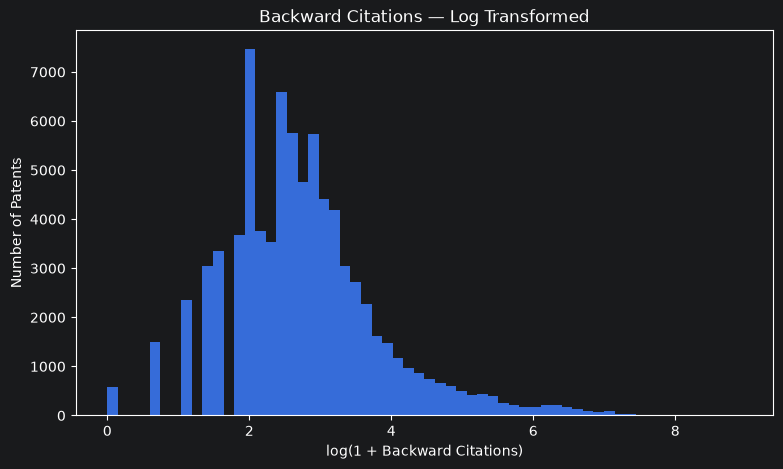

In [19]:
plt.figure(figsize=(9, 5))

plt.hist(
    np.log1p(
        df["backward_citation_count"].dropna()
    ),
    bins=60
)

plt.title("Backward Citations — Log Transformed")
plt.xlabel("log(1 + Backward Citations)")
plt.ylabel("Number of Patents")

plt.show()

In [20]:
df["filing_to_grant_days"].describe()

count    79791.000000
mean      1046.658896
std       1050.189777
min         70.000000
25%        690.000000
50%        985.000000
75%       1314.000000
max      46124.000000
Name: filing_to_grant_days, dtype: float64

In [21]:
df["filing_to_grant_years"] = (
    df["filing_to_grant_days"] / 365.25
)

df["filing_to_grant_years"].describe()

count    79791.000000
mean         2.865596
std          2.875263
min          0.191650
25%          1.889117
50%          2.696783
75%          3.597536
max        126.280630
Name: filing_to_grant_years, dtype: float64

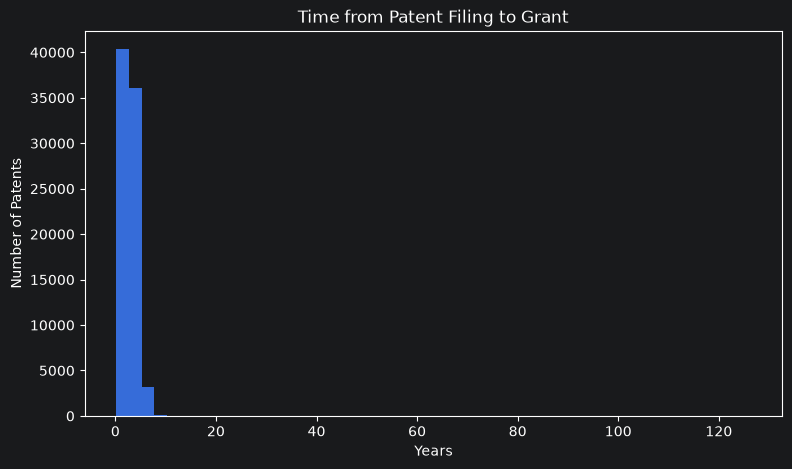

In [22]:
plt.figure(figsize=(9, 5))

plt.hist(
    df["filing_to_grant_years"].dropna(),
    bins=50
)

plt.title("Time from Patent Filing to Grant")
plt.xlabel("Years")
plt.ylabel("Number of Patents")

plt.show()

In [23]:
df["claims_text_length"].describe()

count    8.056600e+04
mean     1.009160e+04
std      1.241274e+04
min      5.570000e+02
25%      7.010250e+03
50%      9.051000e+03
75%      1.169200e+04
max      2.605094e+06
Name: claims_text_length, dtype: float64

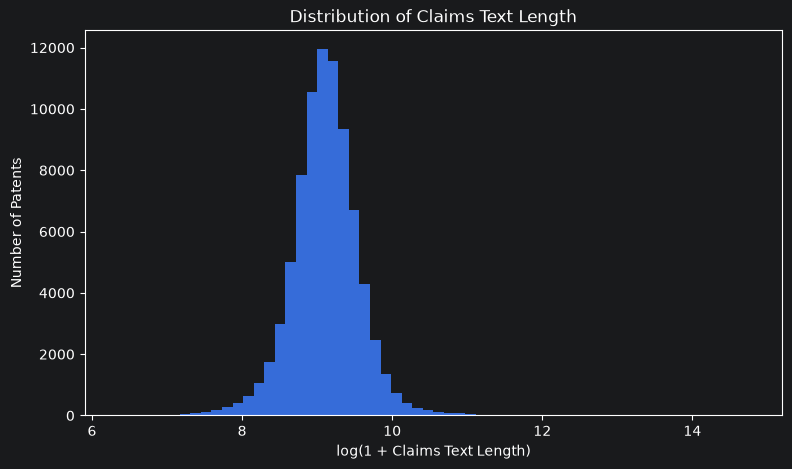

In [24]:
plt.figure(figsize=(9, 5))

plt.hist(
    np.log1p(
        df["claims_text_length"].dropna()
    ),
    bins=60
)

plt.title("Distribution of Claims Text Length")
plt.xlabel("log(1 + Claims Text Length)")
plt.ylabel("Number of Patents")

plt.show()

In [25]:
technology_year = (
    df.groupby(["grant_year", "cpc_group"])
    .size()
    .reset_index(name="patent_count")
)

technology_year.head()

,grant_year,cpc_group,patent_count
0,2021,G06N10,297
1,2021,G06N20,2740
2,2021,G06N3,5124
3,2021,G06N5,1882
4,2021,G06N7,1189


In [26]:
top_technology_groups = (
    df["cpc_group"]
    .value_counts()
    .head(6)
    .index
)

top_technology_groups

Index(['G06N3', 'G06N20', 'G06N5', 'G06N7', 'G06N10', 'G06N99'], dtype='str', name='cpc_group')

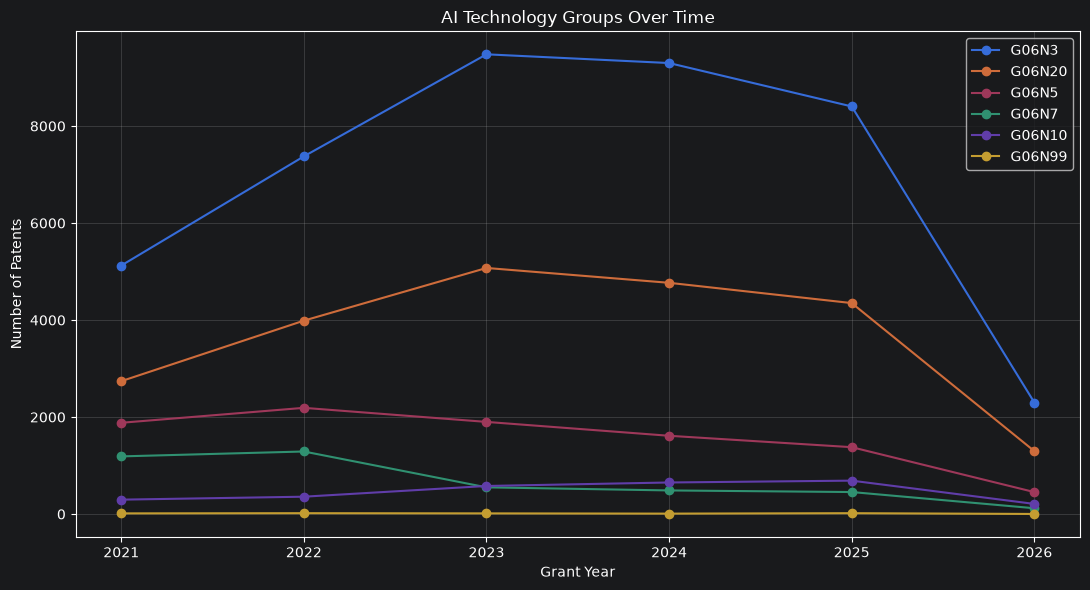

In [27]:
technology_year_top = technology_year[
    technology_year["cpc_group"]
    .isin(top_technology_groups)
]

plt.figure(figsize=(11, 6))

for group in top_technology_groups:

    subset = technology_year_top[
        technology_year_top["cpc_group"] == group
    ]

    plt.plot(
        subset["grant_year"],
        subset["patent_count"],
        marker="o",
        label=group
    )

plt.title("AI Technology Groups Over Time")
plt.xlabel("Grant Year")
plt.ylabel("Number of Patents")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [28]:
technology_share = technology_year.copy()

technology_share["year_total"] = (
    technology_share
    .groupby("grant_year")["patent_count"]
    .transform("sum")
)

technology_share["share_percent"] = (
    technology_share["patent_count"]
    / technology_share["year_total"]
    * 100
)

technology_share.head()

,grant_year,cpc_group,patent_count,year_total,share_percent
0,2021,G06N10,297,11246,2.640939
1,2021,G06N20,2740,11246,24.364218
2,2021,G06N3,5124,11246,45.562867
3,2021,G06N5,1882,11246,16.734839
4,2021,G06N7,1189,11246,10.572648


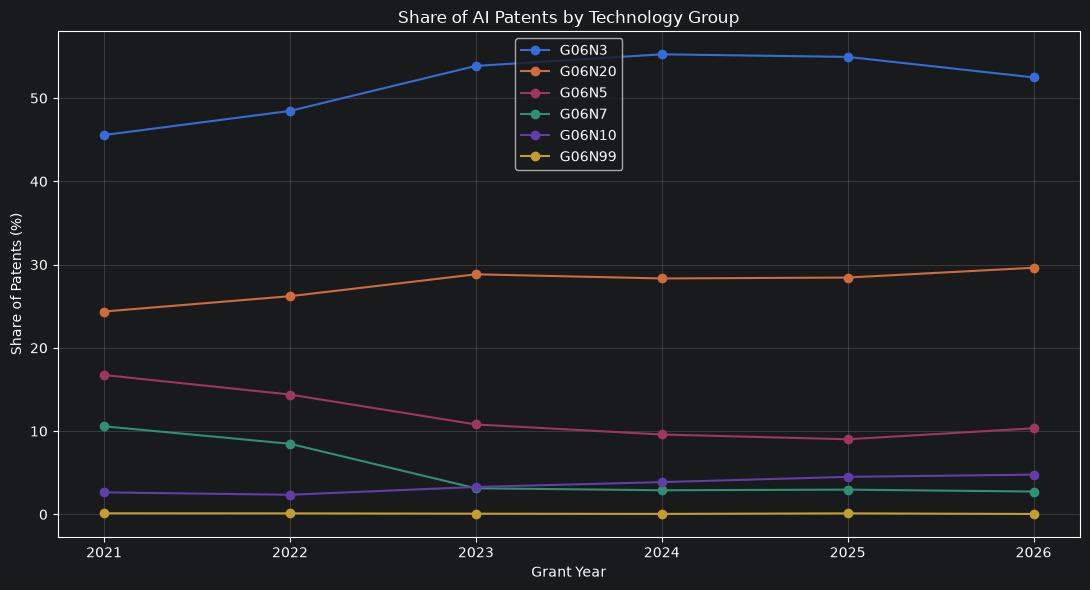

In [29]:
technology_share_top = technology_share[
    technology_share["cpc_group"]
    .isin(top_technology_groups)
]

plt.figure(figsize=(11, 6))

for group in top_technology_groups:

    subset = technology_share_top[
        technology_share_top["cpc_group"] == group
    ]

    plt.plot(
        subset["grant_year"],
        subset["share_percent"],
        marker="o",
        label=group
    )

plt.title("Share of AI Patents by Technology Group")
plt.xlabel("Grant Year")
plt.ylabel("Share of Patents (%)")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [30]:
top_10_assignees = (
    df[df["primary_assignee"] != "Unknown"]
    ["primary_assignee"]
    .value_counts()
    .head(10)
    .index
)

In [31]:
assignee_year = (
    df[
        df["primary_assignee"]
        .isin(top_10_assignees)
    ]
    .groupby(
        ["grant_year", "primary_assignee"]
    )
    .size()
    .reset_index(name="patent_count")
)

assignee_year.head()

,grant_year,primary_assignee,patent_count
0,2021,ADOBE INC,153
1,2021,AMAZON TECH INC,166
2,2021,BANK OF AMERICA,108
3,2021,CAPITAL ONE SERVICES LLC,170
4,2021,GOOGLE LLC,204


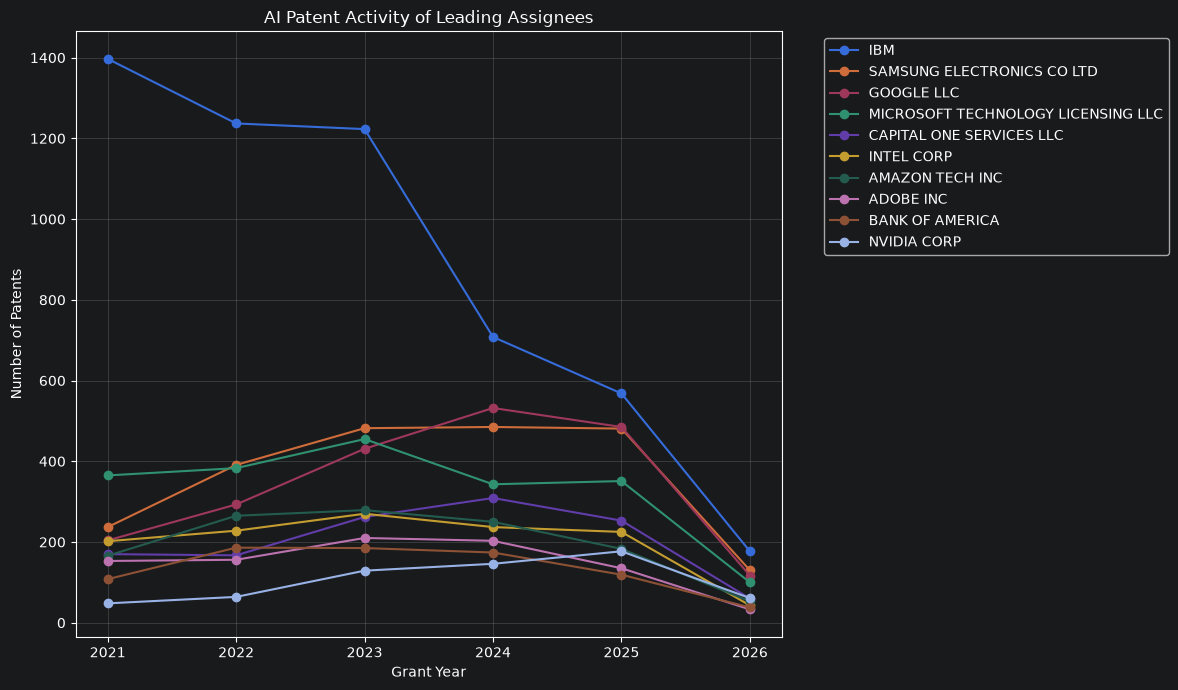

In [32]:
plt.figure(figsize=(12, 7))

for company in top_10_assignees:

    subset = assignee_year[
        assignee_year["primary_assignee"]
        == company
    ]

    plt.plot(
        subset["grant_year"],
        subset["patent_count"],
        marker="o",
        label=company
    )

plt.title("AI Patent Activity of Leading Assignees")
plt.xlabel("Grant Year")
plt.ylabel("Number of Patents")

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [33]:
assignee_technology = (
    df[
        df["primary_assignee"]
        .isin(top_10_assignees)
    ]
    .groupby(
        ["primary_assignee", "cpc_group"]
    )
    .size()
    .reset_index(name="patent_count")
)

assignee_technology.head()

,primary_assignee,cpc_group,patent_count
0,ADOBE INC,G06N20,138
1,ADOBE INC,G06N3,645
2,ADOBE INC,G06N5,63
3,ADOBE INC,G06N7,44
4,AMAZON TECH INC,G06N10,50


In [34]:
assignee_technology_pivot = (
    assignee_technology
    .pivot(
        index="primary_assignee",
        columns="cpc_group",
        values="patent_count"
    )
    .fillna(0)
)

assignee_technology_pivot

cpc_group,G06N10,G06N20,G06N3,G06N5,G06N7,G06N99
primary_assignee,,,,,,
ADOBE INC,0.0,138.0,645.0,63.0,44.0,0.0
AMAZON TECH INC,50.0,393.0,535.0,152.0,64.0,2.0
BANK OF AMERICA,41.0,417.0,204.0,130.0,18.0,0.0
CAPITAL ONE SERVICES LLC,0.0,499.0,512.0,174.0,36.0,0.0
GOOGLE LLC,211.0,433.0,1238.0,127.0,52.0,1.0
IBM,487.0,1419.0,2061.0,1032.0,309.0,2.0
INTEL CORP,81.0,178.0,858.0,60.0,27.0,1.0
MICROSOFT TECHNOLOGY LICENSING LLC,124.0,642.0,883.0,250.0,97.0,1.0
NVIDIA CORP,0.0,47.0,550.0,18.0,10.0,0.0


In [35]:
assignee_technology_pivot.to_csv(
    TABLES_DIR /
    "eda_assignee_technology.csv"
)

In [36]:
company_main_technology = (
    assignee_technology
    .sort_values(
        ["primary_assignee", "patent_count"],
        ascending=[True, False]
    )
    .groupby("primary_assignee")
    .first()
    .reset_index()
)

company_main_technology

,primary_assignee,cpc_group,patent_count
0,ADOBE INC,G06N3,645
1,AMAZON TECH INC,G06N3,535
2,BANK OF AMERICA,G06N20,417
3,CAPITAL ONE SERVICES LLC,G06N3,512
4,GOOGLE LLC,G06N3,1238
5,IBM,G06N3,2061
6,INTEL CORP,G06N3,858
7,MICROSOFT TECHNOLOGY LICENSING LLC,G06N3,883
8,NVIDIA CORP,G06N3,550
9,SAMSUNG ELECTRONICS CO LTD,G06N3,1764


In [37]:
top_country_names = (
    df[
        df["assignee_country"] != "Unknown"
    ]
    ["assignee_country"]
    .value_counts()
    .head(10)
    .index
)

In [38]:
country_technology = (
    df[
        df["assignee_country"]
        .isin(top_country_names)
    ]
    .groupby(
        ["assignee_country", "cpc_group"]
    )
    .size()
    .reset_index(name="patent_count")
)

country_technology.head()

,assignee_country,cpc_group,patent_count
0,CA,G06N10,126
1,CA,G06N20,353
2,CA,G06N3,614
3,CA,G06N5,176
4,CA,G06N7,59


In [39]:
country_technology_pivot = (
    country_technology
    .pivot(
        index="assignee_country",
        columns="cpc_group",
        values="patent_count"
    )
    .fillna(0)
)

country_technology_pivot

cpc_group,G06N10,G06N20,G06N3,G06N5,G06N7,G06N99
assignee_country,,,,,,
CA,126.0,353.0,614.0,176.0,59.0,1.0
CN,83.0,654.0,3904.0,329.0,172.0,3.0
DE,35.0,514.0,1307.0,231.0,93.0,0.0
GB,47.0,225.0,839.0,125.0,57.0,0.0
IE,27.0,231.0,275.0,181.0,48.0,0.0
IL,82.0,381.0,457.0,106.0,36.0,0.0
JP,95.0,1214.0,2657.0,419.0,231.0,18.0
KR,42.0,873.0,3970.0,192.0,90.0,9.0
TW,12.0,169.0,615.0,43.0,32.0,0.0


In [40]:
country_technology_pivot.to_csv(
    TABLES_DIR /
    "eda_country_technology.csv"
)

In [41]:
technology_characteristics = (
    df.groupby("cpc_group")
    .agg(
        patents=(
            "publication_number",
            "count"
        ),

        avg_inventors=(
            "inventor_count",
            "mean"
        ),

        avg_cpc_count=(
            "cpc_count",
            "mean"
        ),

        avg_backward_citations=(
            "backward_citation_count",
            "mean"
        ),

        avg_claims_words=(
            "claims_word_count",
            "mean"
        ),

        avg_grant_days=(
            "filing_to_grant_days",
            "mean"
        )
    )
    .round(2)
    .sort_values(
        "patents",
        ascending=False
    )
)

technology_characteristics

,patents,avg_inventors,avg_cpc_count,avg_backward_citations,avg_claims_words,avg_grant_days
cpc_group,,,,,,
G06N3,41981,3.58,15.17,34.95,1447.36,1044.38
G06N20,22218,3.50,11.10,39.56,1489.96,1035.48
G06N5,9418,3.57,11.76,39.69,1574.85,1066.48
G06N7,4091,3.50,12.81,44.54,1520.88,1099.44
G06N10,2783,3.25,7.68,25.00,1206.22,1021.62
G06N99,75,4.32,45.75,277.97,1260.64,1204.77


In [42]:
technology_characteristics.to_csv(
    TABLES_DIR /
    "eda_technology_characteristics.csv"
)

In [43]:
correlation_columns = [
    "inventor_count",
    "assignee_count",
    "cpc_count",
    "backward_citation_count",
    "title_word_count",
    "abstract_word_count",
    "claims_word_count",
    "filing_to_grant_days"
]

correlation_matrix = (
    df[correlation_columns]
    .corr()
    .round(2)
)

correlation_matrix

,inventor_count,assignee_count,cpc_count,backward_citation_count,title_word_count,abstract_word_count,claims_word_count,filing_to_grant_days
inventor_count,1.00,0.06,0.05,0.03,-0.02,0.00,0.03,-0.01
assignee_count,0.06,1.00,0.01,-0.02,0.01,-0.02,-0.01,0.01
cpc_count,0.05,0.01,1.00,0.29,0.03,-0.02,-0.00,-0.04
backward_citation_count,0.03,-0.02,0.29,1.00,0.02,-0.03,0.01,-0.01
title_word_count,-0.02,0.01,0.03,0.02,1.00,0.08,0.05,-0.01
abstract_word_count,0.00,-0.02,-0.02,-0.03,0.08,1.00,0.11,-0.01
claims_word_count,0.03,-0.01,-0.00,0.01,0.05,0.11,1.00,0.01
filing_to_grant_days,-0.01,0.01,-0.04,-0.01,-0.01,-0.01,0.01,1.00


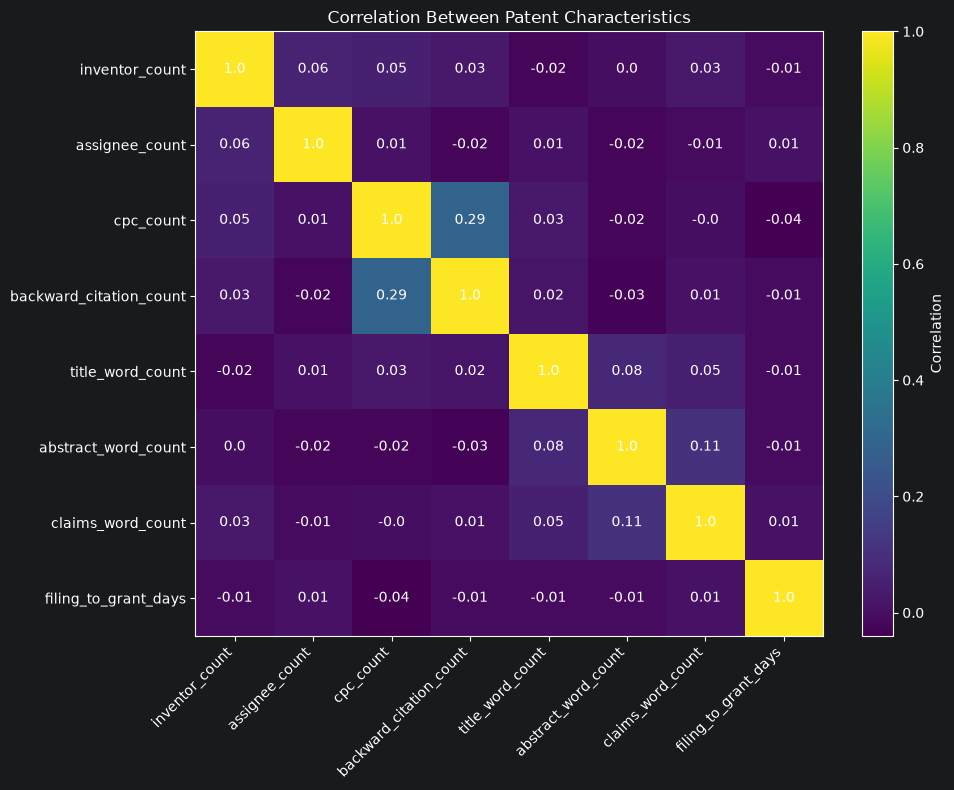

In [44]:
plt.figure(figsize=(10, 8))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar(
    label="Correlation"
)

plt.xticks(
    range(len(correlation_columns)),
    correlation_columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_columns)),
    correlation_columns
)

for i in range(len(correlation_columns)):
    for j in range(len(correlation_columns)):

        plt.text(
            j,
            i,
            correlation_matrix.iloc[i, j],
            ha="center",
            va="center"
        )

plt.title(
    "Correlation Between Patent Characteristics"
)

plt.tight_layout()
plt.show()

In [45]:
plot_df = df[
    [
        "cpc_count",
        "backward_citation_count"
    ]
].dropna()

In [46]:
sample_df = plot_df.sample(
    n=min(10000, len(plot_df)),
    random_state=42
)

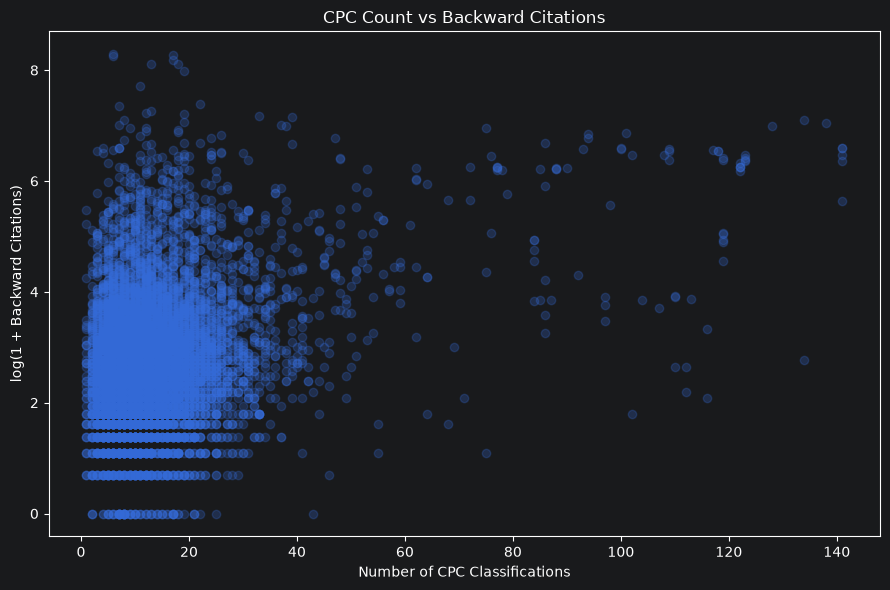

In [47]:
plt.figure(figsize=(9, 6))

plt.scatter(
    sample_df["cpc_count"],
    np.log1p(
        sample_df["backward_citation_count"]
    ),
    alpha=0.25
)

plt.title(
    "CPC Count vs Backward Citations"
)

plt.xlabel(
    "Number of CPC Classifications"
)

plt.ylabel(
    "log(1 + Backward Citations)"
)

plt.tight_layout()
plt.show()

In [48]:
sample_df = (
    df[
        [
            "inventor_count",
            "cpc_count"
        ]
    ]
    .dropna()
    .sample(
        n=min(
            10000,
            len(df.dropna(
                subset=[
                    "inventor_count",
                    "cpc_count"
                ]
            ))
        ),
        random_state=42
    )
)

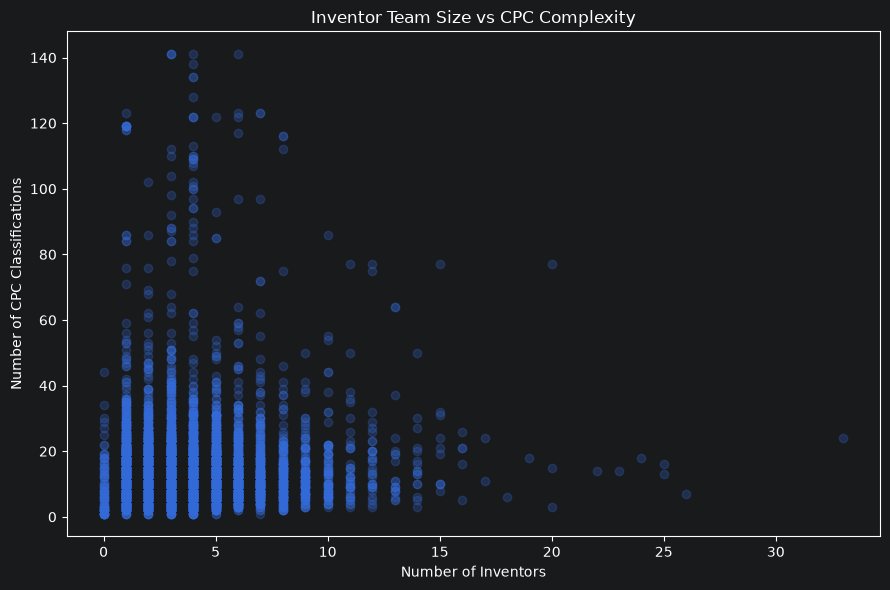

In [49]:
plt.figure(figsize=(9, 6))

plt.scatter(
    sample_df["inventor_count"],
    sample_df["cpc_count"],
    alpha=0.25
)

plt.title(
    "Inventor Team Size vs CPC Complexity"
)

plt.xlabel(
    "Number of Inventors"
)

plt.ylabel(
    "Number of CPC Classifications"
)

plt.tight_layout()
plt.show()

In [50]:
grant_time_by_technology = (
    df.groupby("cpc_group")
    ["filing_to_grant_days"]
    .agg([
        "count",
        "median",
        "mean"
    ])
    .round(0)
    .sort_values(
        "median"
    )
)

grant_time_by_technology

,count,median,mean
cpc_group,,,
G06N20,22012,967.0,1035.0
G06N10,2755,977.0,1022.0
G06N3,41584,985.0,1044.0
G06N5,9324,1010.0,1066.0
G06N7,4043,1035.0,1099.0
G06N99,73,1175.0,1205.0


In [51]:
grant_time_by_technology[
    "median_years"
] = (
    grant_time_by_technology["median"]
    / 365.25
).round(2)

grant_time_by_technology[
    "mean_years"
] = (
    grant_time_by_technology["mean"]
    / 365.25
).round(2)

grant_time_by_technology

,count,median,mean,median_years,mean_years
cpc_group,,,,,
G06N20,22012,967.0,1035.0,2.65,2.83
G06N10,2755,977.0,1022.0,2.67,2.80
G06N3,41584,985.0,1044.0,2.70,2.86
G06N5,9324,1010.0,1066.0,2.77,2.92
G06N7,4043,1035.0,1099.0,2.83,3.01
G06N99,73,1175.0,1205.0,3.22,3.30


In [52]:
annual_growth = (
    patents_by_year
    .copy()
)

annual_growth[
    "growth_percent"
] = (
    annual_growth["patent_count"]
    .pct_change()
    * 100
).round(2)

annual_growth

,grant_year,patent_count,growth_percent
0,2021,11246,NaN
1,2022,15219,35.33
2,2023,17597,15.63
3,2024,16828,-4.37
4,2025,15294,-9.12
5,2026,4382,-71.35


In [53]:
completed_year_growth = (
    annual_growth[
        annual_growth["grant_year"] <= 2025
    ]
)

completed_year_growth

,grant_year,patent_count,growth_percent
0,2021,11246,NaN
1,2022,15219,35.33
2,2023,17597,15.63
3,2024,16828,-4.37
4,2025,15294,-9.12


In [54]:
patents_by_year.to_csv(
    TABLES_DIR /
    "eda_patents_by_year.csv",
    index=False
)

top_assignees.to_csv(
    TABLES_DIR /
    "eda_top_assignees.csv",
    index=False
)

country_counts.to_csv(
    TABLES_DIR /
    "eda_country_counts.csv",
    index=False
)

cpc_group_counts.to_csv(
    TABLES_DIR /
    "eda_cpc_groups.csv",
    index=False
)

correlation_matrix.to_csv(
    TABLES_DIR /
    "eda_correlation_matrix.csv"
)

annual_growth.to_csv(
    TABLES_DIR /
    "eda_annual_growth.csv",
    index=False
)